# 02 — Index numbers, LMDI, PVM, shift–share, and SDA

**Graduate course: Decomposition Analysis in Python**

## Learning objectives

- Derive and compare Laspeyres, Paasche, and Fisher indexes.
- Prove additive LMDI exactness and implement additive and multiplicative interpretations.
- Distinguish price, volume, genuine mix, and interaction conventions.
- Derive classical shift–share and interpret its benchmark-relative residual.
- Derive a symmetric two-factor structural decomposition using the Leontief model.

## Roadmap and notation

### Guiding question

How can a change in a total generated by several multiplicative factors be allocated without leaving an unexplained residual?

### Prerequisites

Products, logarithms, matrix multiplication, and before/after comparisons. Differential and matrix arguments are derived explicitly; the Python examples require only basic NumPy and pandas usage.

### Symbols

- $i$: product, channel, sector, or other component.
- $Q_{it}$: activity or quantity; $I_{it}$: intensity or rate.
- $E_{it}=Q_{it}I_{it}$: component total.
- $L(a,b)$: logarithmic mean, a symmetric weight between positive $a$ and $b$.
- $p_{it},q_{it}$: price and quantity in PVM/index-number notation.

The sequence moves from scalar indexes to exact multiplicative decomposition, business revenue bridges, benchmark-relative growth, and finally matrix systems. Each method receives a separate derivation because their outputs are not interchangeable.

## Overview: identities and allocation rules

If emissions $E=\sum_i Q_i I_i$, the additive LMDI uses the logarithmic mean $L(a,b)=(a-b)/(\log a-\log b)$:
$$\Delta E_Q=\sum_iL(E_{i1},E_{i0})\log(Q_{i1}/Q_{i0}),\quad
\Delta E_I=\sum_iL(E_{i1},E_{i0})\log(I_{i1}/I_{i0}).$$
It is exact for positive values and has no residual. PVM applies the same identity logic to revenue $\sum_i p_iq_i$, but common business conventions allocate the interaction differently. Laspeyres uses base weights; Fisher is the geometric mean of Laspeyres and Paasche indexes. Shift–share partitions regional change into national, industry-mix, and regional-competitive terms. SDA applies polar/average or all-permutation rules to input–output identities.

## 1. Index numbers: Laspeyres, Paasche, and Fisher

### The problem

For several products, total expenditure or revenue is

$$V_t=\sum_{i=1}^n p_{it}q_{it}.$$

The value ratio $V_1/V_0$ combines price and quantity changes. An index-number system seeks price and quantity indexes satisfying approximately or exactly

$$\frac{V_1}{V_0}=P(0,1)Q(0,1).$$

### Fixed-weight indexes

The Laspeyres price index values current prices using baseline quantities:

$$P_L=\frac{\sum_i p_{i1}q_{i0}}{\sum_i p_{i0}q_{i0}}.$$

The Paasche price index uses current quantities:

$$P_P=\frac{\sum_i p_{i1}q_{i1}}{\sum_i p_{i0}q_{i1}}.$$

Their quantity counterparts are

$$Q_L=\frac{\sum_i p_{i0}q_{i1}}{\sum_i p_{i0}q_{i0}},\qquad
Q_P=\frac{\sum_i p_{i1}q_{i1}}{\sum_i p_{i1}q_{i0}}.$$

Laspeyres tends to overweight goods that were important in the base period; Paasche uses the comparison-period basket and may reflect substitution that already occurred. Neither is universally “correct”: they answer different basket questions.

### Fisher's symmetric index and factor reversal

Fisher takes geometric means:

$$P_F=\sqrt{P_LP_P},\qquad Q_F=\sqrt{Q_LQ_P}.$$

Because $P_LQ_P=V_1/V_0$ and $P_PQ_L=V_1/V_0$,

$$P_FQ_F=\sqrt{P_LP_PQ_LQ_P}=\frac{V_1}{V_0}.$$

Thus Fisher passes the **factor-reversal test** exactly. It also passes the time-reversal test: reversing periods gives the reciprocal index. Diewert (1976) called Fisher “superlative” because it is exact for a flexible quadratic aggregator and provides a second-order approximation to broad preference/technology structures.

Index numbers summarize relative change; they do not estimate demand elasticities or causal price effects.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import permutations, combinations
pd.options.display.float_format = '{:,.4f}'.format
plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

In [2]:
x = pd.DataFrame({
    'product': ['A', 'B', 'C'],
    'q0': [100, 80, 50],
    'q1': [115, 70, 66],
    'i0': [2.0, 3.0, 5.0],
    'i1': [1.8, 3.4, 4.6],
})
x['E0'] = x.q0 * x.i0
x['E1'] = x.q1 * x.i1

def L(a,b):
    # Logarithmic mean, using its continuous value when a equals b.
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.where(np.isclose(a, b), a, (a - b) / (np.log(a) - np.log(b)))

log_weights = L(x.E1, x.E0)
x['activity'] = log_weights * np.log(x.q1 / x.q0)
x['intensity'] = log_weights * np.log(x.i1 / x.i0)

lmdi_summary = pd.Series({
    'observed': x.E1.sum() - x.E0.sum(),
    'activity': x.activity.sum(),
    'intensity': x.intensity.sum(),
    'residual': (x.E1 - x.E0 - x.activity - x.intensity).sum(),
})
x, lmdi_summary

(  product   q0   q1     i0     i1       E0       E1  activity  intensity
 0       A  100  115 2.0000 1.8000 200.0000 207.0000   28.4388   -21.4388
 1       B   80   70 3.0000 3.4000 240.0000 238.0000  -31.9138    29.9138
 2       C   50   66 5.0000 4.6000 250.0000 303.6000   76.6077   -23.0077,
 observed     58.6000
 activity     73.1327
 intensity   -14.5327
 residual      0.0000
 dtype: float64)

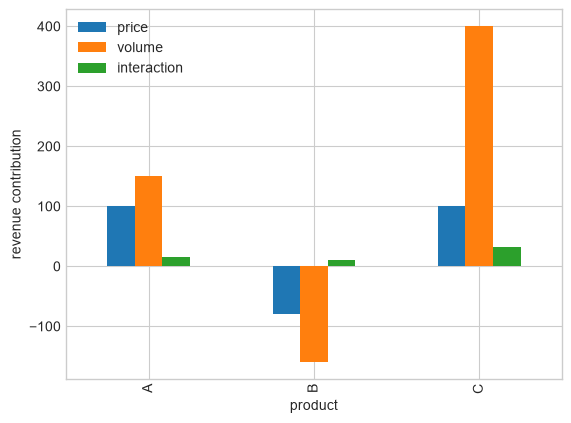

In [3]:
p0 = np.array([10., 16., 25.])
p1 = np.array([11., 15., 27.])
q0 = x.q0.to_numpy()
q1 = x.q1.to_numpy()

price = (p1 - p0) * q0
volume = p0 * (q1 - q0)
interaction = (p1 - p0) * (q1 - q0)

pvm = pd.DataFrame({
    'product': x['product'],
    'price': price,
    'volume': volume,
    'interaction': interaction,
}).set_index('product')
pvm.plot.bar()
plt.ylabel('revenue contribution')
plt.show()

## Reading the worked examples

The first table shows an observed total increase of 58.6. Activity contributes +73.13 while intensity contributes −14.53; these sum exactly to 58.6. Intensity therefore offsets part of the activity-driven increase. The zero residual is an algebraic property of LMDI for these positive data.

The PVM chart answers a different question. Its bars use base-period quantities and prices, while the interaction is shown separately. A large price bar is not a demand elasticity and does not estimate what quantity would have been under a different price.

## Business and growth setting

This notebook uses a common hierarchy:

$$\text{Revenue}=\sum_i p_iq_i,$$

and, for a digital funnel,

$$\text{Revenue}=\text{Impressions}\times\text{CTR}
\times\text{CVR}\times\text{AOV}.$$

Index numbers summarize price and quantity change across products. PVM allocates an absolute revenue change. LMDI allocates multiplicative driver changes. Shift–share compares growth across channels or markets. SDA handles systems in which outputs depend on matrices of interdependencies.

A second identity,

$$\text{Profit}=\text{Revenue}-\text{Spend},\qquad
\text{Spend}=\text{Clicks}\times\text{CPC},$$

prevents a favorable gross-revenue attribution from being mistaken for incremental profit.

In [4]:
# Compare bilateral price and quantity indexes on the same products.
index_data = pd.DataFrame({
    'product': ['A', 'B', 'C'],
    'p0': [10., 16., 25.],
    'p1': [11., 15., 27.],
    'q0': [100., 80., 50.],
    'q1': [115., 70., 66.],
})

p0_i, p1_i = index_data.p0, index_data.p1
q0_i, q1_i = index_data.q0, index_data.q1
V0 = (p0_i*q0_i).sum()
V1 = (p1_i*q1_i).sum()

P_L = (p1_i*q0_i).sum() / V0
P_P = V1 / (p0_i*q1_i).sum()
Q_L = (p0_i*q1_i).sum() / V0
Q_P = V1 / (p1_i*q0_i).sum()
P_F = np.sqrt(P_L*P_P)
Q_F = np.sqrt(Q_L*Q_P)

pd.Series({
    'value ratio V1/V0': V1/V0,
    'Laspeyres price': P_L,
    'Paasche price': P_P,
    'Fisher price': P_F,
    'Laspeyres quantity': Q_L,
    'Paasche quantity': Q_P,
    'Fisher quantity': Q_F,
    'Fisher factor-reversal error': P_F*Q_F - V1/V0,
})

value ratio V1/V0               1.1606
Laspeyres price                 1.0340
Paasche price                   1.0452
Fisher price                    1.0396
Laspeyres quantity              1.1105
Paasche quantity                1.1225
Fisher quantity                 1.1165
Fisher factor-reversal error   -0.0000
dtype: float64

### Reading the index-number output

Laspeyres and Paasche differ because they use different baskets. Fisher lies between them and its price index multiplied by its quantity index reproduces the observed value ratio, as shown by the near-zero factor-reversal error.

For pricing analytics, report which basket is used. A statement such as “prices increased 4%” is incomplete without the index formula, product coverage, treatment of new/disappearing products, and whether indexes are bilateral or chained.

## 2. Divisia and LMDI

### From infinitesimal change to finite decomposition

For a differentiable aggregate $Y=F(x_1,\ldots,x_K)$, a Divisia decomposition follows the total differential

$$dY=\sum_{k=1}^K\frac{\partial F}{\partial x_k}dx_k,$$

or in logarithmic form

$$d\log Y=\sum_k\frac{\partial\log F}{\partial\log x_k}d\log x_k.$$

This identity is exact for infinitesimal changes. Discrete data require an integration or index approximation. For an additive aggregate

$$E_t=\sum_i E_{it},\qquad E_{it}=\prod_{k=1}^K x_{kit},$$

define the logarithmic mean

$$L(a,b)=\begin{cases}
\dfrac{a-b}{\log a-\log b},&a\ne b,\\[4pt]
a,&a=b.
\end{cases}$$

The additive LMDI contribution of factor $k$ is

$$\boxed{\Delta E_k=\sum_iL(E_{i1},E_{i0})
\log\left(\frac{x_{ki1}}{x_{ki0}}\right)}.$$

### Proof of perfect decomposition

For each component,

$$\sum_k\log\left(\frac{x_{ki1}}{x_{ki0}}\right)
=\log\left(\frac{E_{i1}}{E_{i0}}\right).$$

Therefore

$$\sum_k\Delta E_k
=\sum_iL(E_{i1},E_{i0})\log(E_{i1}/E_{i0})
=\sum_i(E_{i1}-E_{i0})=E_1-E_0.$$

The second equality follows directly from the definition of $L$. Hence LMDI has no unexplained residual for positive data.

The multiplicative form uses

$$D_k=\exp\left(\sum_i\frac{L(E_{i1},E_{i0})}{L(E_1,E_0)}
\log\frac{x_{ki1}}{x_{ki0}}\right),\qquad
\prod_kD_k=\frac{E_1}{E_0}.$$

Additive and multiplicative forms express the same comparison in absolute and ratio units, respectively.

In [5]:
# Growth funnel: exact LMDI allocation of revenue change
f0 = pd.Series({'impressions': 1_000_000., 'ctr': .020, 'cvr': .040, 'aov': 55.})
f1 = pd.Series({'impressions': 1_150_000., 'ctr': .023, 'cvr': .037, 'aov': 58.})
y0, y1 = f0.prod(), f1.prod()
weight = L(np.array([y1]), np.array([y0]))[0]
funnel_contrib = weight * np.log(f1/f0)
funnel_result = pd.concat([
    funnel_contrib.rename('absolute contribution'),
    (100*funnel_contrib/(y1-y0)).rename('share of change (%)'),
], axis=1)
funnel_result.loc['sum / observed change'] = [funnel_contrib.sum(), 100.]
funnel_result

,absolute contribution,share of change (%)
impressions,"7,003.5135",54.8792
ctr,"7,003.5135",54.8792
cvr,"-3,906.6766",-30.6125
aov,"2,661.3495",20.8542
sum / observed change,"12,761.7000",100.0000


### Reading the growth-funnel LMDI

The contributions sum to the observed revenue change. Impressions, CTR, and AOV contribute positively; CVR contributes negatively because it falls. A negative CVR contribution does not prove that a campaign harmed conversion—it describes the arithmetic role of the observed CVR movement.

Growth applications include revenue waterfalls, CAC identities, energy-like decompositions of marketing spend, and cohort LTV factorizations. Always state units and factorization. `Impressions × CTR × CVR × AOV` and `Clicks × orders-per-click × AOV` are algebraically compatible but create different reporting levels.

## 3. Price–Volume–Mix (PVM)

### One product

For revenue $R=pq$,

$$\Delta R=q_0\Delta p+p_0\Delta q+\Delta p\Delta q.$$

The three terms are baseline-weighted price, baseline-weighted volume, and interaction. Three common exact conventions are:

1. **Explicit interaction:** report all three terms.
2. **Price-first:** $C_p=q_0\Delta p$ and $C_q=p_1\Delta q$.
3. **Symmetric:** split interaction equally:

$$C_p=\Delta p\frac{q_0+q_1}{2},\qquad
C_q=\Delta q\frac{p_0+p_1}{2}.$$

All sum to $\Delta R$, but individual contributions differ.

### Multiple products and genuine mix

Write $q_i=Qs_i$, where $Q=\sum_iq_i$ is total units and $s_i=q_i/Q$ is product share. Then

$$R=Q\sum_i p_is_i=Q\bar p.$$

A change in product shares is distinct from a change in total units. A useful decomposition must separate total volume from mix rather than labeling every product-level quantity change “mix.” Because $Q$, $s$, and $p$ interact, the analyst must state the interaction rule—base weights, symmetric polar average, LMDI, or all-orders/Shapley.

In [6]:
# Compare three exact PVM conventions for one product.
p0_one, p1_one = 50., 48.
q0_one, q1_one = 40., 60.
dp, dq = p1_one-p0_one, q1_one-q0_one
observed_change = p1_one*q1_one - p0_one*q0_one

pvm_conventions = pd.DataFrame({
    'explicit interaction': [q0_one*dp, p0_one*dq, dp*dq],
    'price first': [q0_one*dp, p1_one*dq, 0.],
    'symmetric split': [dp*(q0_one+q1_one)/2,
                        dq*(p0_one+p1_one)/2, 0.],
}, index=['price','volume','interaction'])
pvm_conventions.loc['allocated total'] = pvm_conventions.sum()
pvm_conventions.loc['observed change'] = observed_change
pvm_conventions

,explicit interaction,price first,symmetric split
price,-80.0000,-80.0000,-100.0000
volume,"1,000.0000",960.0000,980.0000
interaction,-40.0000,0.0000,0.0000
allocated total,880.0000,880.0000,880.0000
observed change,880.0000,880.0000,880.0000


### PVM applications and econometric interpretation

PVM is useful for financial planning, SKU revenue bridges, subscription plan migration, and separating AOV from order growth. In paid growth, an analogous bridge can separate CPC, clicks, conversion, and order value.

Limitations:

- Results depend on interaction convention and base period.
- New/discontinued products require explicit entry/exit treatment.
- Discounts, returns, taxes, and currency effects can make “price” ambiguous.
- Observed price and quantity are jointly determined; the price contribution is not a demand curve or elasticity.
- Product-mix shifts can be endogenous to promotions, availability, and customer selection.

For a causal pricing question, estimate what quantity and mix would have occurred under the alternative price policy; do not freeze observed quantity mechanically.

## 4. Shift–share decomposition

Shift–share was developed for regional employment analysis but transfers naturally to channels, geographies, products, and customer segments. Let $E_{ir0}$ be baseline activity in industry/channel $i$ and region/business unit $r$. Define national/portfolio growth $g$, category growth $g_i$, and local category growth $g_{ir}$.

The classical change is decomposed as

$$\Delta E_{ir}=
\underbrace{E_{ir0}g}_{\text{overall growth}}
+\underbrace{E_{ir0}(g_i-g)}_{\text{category mix}}
+\underbrace{E_{ir0}(g_{ir}-g_i)}_{\text{local competitive shift}}.$$

The proof is immediate:

$$g+(g_i-g)+(g_{ir}-g_i)=g_{ir}.$$

Multiplying by $E_{ir0}$ recovers $E_{ir0}g_{ir}=E_{ir1}-E_{ir0}$.

The “competitive” residual is a benchmark-relative descriptive term. It is not evidence that local management or a campaign caused superior growth.

In [7]:
# Marketing shift–share: conversions by channel in one region.
shift_share = pd.DataFrame({
    'channel': ['Search', 'Social', 'Email'],
    'local_0': [500., 300., 200.],
    'local_1': [570., 390., 218.],
    'portfolio_0': [5_000., 4_000., 2_000.],
    'portfolio_1': [5_400., 4_800., 2_100.],
})
portfolio_total_growth = (
    shift_share.portfolio_1.sum()/shift_share.portfolio_0.sum()-1
)
shift_share['category_growth'] = (
    shift_share.portfolio_1/shift_share.portfolio_0-1
)
shift_share['local_growth'] = shift_share.local_1/shift_share.local_0-1
shift_share['overall'] = shift_share.local_0*portfolio_total_growth
shift_share['category_mix'] = shift_share.local_0*(
    shift_share.category_growth-portfolio_total_growth
)
shift_share['local_shift'] = shift_share.local_0*(
    shift_share.local_growth-shift_share.category_growth
)
shift_share['observed_change'] = shift_share.local_1-shift_share.local_0
shift_share['identity_error'] = (
    shift_share[['overall','category_mix','local_shift']].sum(axis=1)
    - shift_share.observed_change
)
shift_share[['channel','overall','category_mix','local_shift',
             'observed_change','identity_error']]

,channel,overall,category_mix,local_shift,observed_change,identity_error
0,Search,59.0909,-19.0909,30.0000,70.0000,-0.0000
1,Social,35.4545,24.5455,30.0000,90.0000,0.0000
2,Email,23.6364,-13.6364,8.0000,18.0000,0.0000


### Shift–share applications and limitations

In growth marketing, overall growth measures the expansion expected if the local unit followed the portfolio; category mix measures exposure to faster/slower-growing channels; local shift measures growth beyond the category benchmark.

- Results are sensitive to benchmark, base year, geographic/channel classification, and analysis window.
- The competitive term is a residual containing measurement error, omitted composition, shocks, and regression-to-the-mean.
- Classical shift–share has no sampling model or causal identification by itself.
- Dynamic shift–share updates weights through time but can change interpretation and introduce path dependence.
- In econometrics, a **Bartik/shift–share instrument** is a different object: causal validity requires exposure shares, shocks, exclusion restrictions, and appropriate inference. The descriptive decomposition does not establish instrument validity.

## 5. Structural Decomposition Analysis (SDA)

SDA decomposes changes in systems represented by matrix identities, especially input–output economics. In the Leontief quantity model,

$$x=Ax+y,$$

where $x$ is gross output, $A$ is the matrix of intermediate-input coefficients, and $y$ is final demand. If $I-A$ is invertible,

$$x=(I-A)^{-1}y=Ly,$$

where $L$ is the Leontief inverse. Between periods,

$$\Delta x=L_1y_1-L_0y_0.$$

Two exact polar decompositions are

$$\Delta x=(L_1-L_0)y_0+L_1(y_1-y_0),$$

and

$$\Delta x=(L_1-L_0)y_1+L_0(y_1-y_0).$$

Their average gives a symmetric two-factor allocation:

$$\Delta x_L=\frac12(L_1-L_0)(y_0+y_1),$$

$$\Delta x_y=\frac12(L_0+L_1)(y_1-y_0).$$

Adding them recovers $\Delta x$. With more determinants—technology, demand level, demand composition, trade, emissions intensity—the number of polar paths increases, motivating average-polar or all-permutation rules.

In [8]:
# Two-sector SDA: technology versus final-demand effects.
A0 = np.array([[.20, .10], [.05, .25]])
A1 = np.array([[.18, .12], [.07, .22]])
y0_sda = np.array([100., 80.])
y1_sda = np.array([118., 86.])
I = np.eye(2)
L0 = np.linalg.inv(I-A0)
L1 = np.linalg.inv(I-A1)
x0_sda = L0 @ y0_sda
x1_sda = L1 @ y1_sda

technology_effect = .5*(L1-L0) @ (y0_sda+y1_sda)
demand_effect = .5*(L0+L1) @ (y1_sda-y0_sda)

pd.DataFrame({
    'technology effect': technology_effect,
    'final-demand effect': demand_effect,
    'allocated change': technology_effect+demand_effect,
    'observed change': x1_sda-x0_sda,
    'identity error': technology_effect+demand_effect-(x1_sda-x0_sda),
}, index=['sector 1','sector 2'])

,technology effect,final-demand effect,allocated change,observed change,identity error
sector 1,-0.8693,23.5408,22.6715,22.6715,-0.0000
sector 2,-0.8419,9.6854,8.8435,8.8435,-0.0000


### SDA applications and limitations

SDA is used for emissions footprints, supply-chain requirements, productivity, trade, and demand propagation. A business analogue is a networked operating model in which acquisition, fulfillment, support, and retention depend on one another through a coefficient matrix.

- Results inherit input–output measurement error and sector aggregation choices.
- The Leontief model assumes fixed linear coefficients within each period and requires $(I-A)^{-1}$ to exist.
- Symmetric polar averaging resolves two-factor order dependence but remains an allocation convention.
- With many factors, exact all-order averaging can become expensive.
- Technology coefficients describe requirements, not necessarily causal production responses under policy intervention.
- Structural change may include prices, capacity constraints, substitution, and behavioral adjustment absent from the fixed-coefficient identity.

## Comparison of the five method families

| Method | Object | Typical output | Exact? | Main choice | Causal by itself? |
|---|---|---|---|---|---|
| Laspeyres/Paasche/Fisher | price–quantity value ratio | price and quantity indexes | Fisher passes factor reversal | weights/base/chaining | no |
| LMDI | positive multiplicative identity | additive or multiplicative factor effects | yes | factorization and zero handling | no |
| PVM | revenue identity | price, volume, mix, interaction | yes under declared rule | interaction convention | no |
| shift–share | benchmarked segment growth | overall, mix, local shift | yes | benchmark and base period | no |
| SDA | matrix structural identity | technology/demand/etc. effects | yes under polar/path rule | determinant order and aggregation | no |

## Econometric point of view

These methods primarily transform observed aggregates or estimated accounting objects. They do not estimate behavioral parameters merely because a component is called price, intensity, competitiveness, or technology.

- A price contribution is not an elasticity.
- A local shift is not a treatment effect.
- An LMDI factor is not a structural coefficient.
- An SDA technology effect is not automatically policy-invariant.

Sampling uncertainty matters when inputs are survey estimates, noisy rates, forecasts, or estimated matrices. Use bootstrap, delta-method, or simulation procedures appropriate to how those inputs were generated. Identification uncertainty cannot be repaired by a zero algebraic residual.

## Limitations and robustness

- Run bilateral and chained index variants and disclose revisions, entry/exit rules, and quality adjustment.
- For LMDI, document zero handling; logarithms require positive values and negative totals can be inadmissible.
- For PVM, compare explicit-interaction, base-weighted, and symmetric allocations.
- For shift–share, repeat with credible benchmarks, base periods, and classifications.
- For SDA, compare the two polar decompositions, their average, and all-order results when feasible.
- Stress-test factorization and aggregation level across every identity method.
- None corrects endogeneity, anticipation, auction feedback, substitution, or interference without a separate econometric/causal design.

## What came next

**Diewert (1976)** formalized exact and superlative indexes. **Ang & Choi (1997)** refined the logarithmic-mean Divisia method; **Ang (2005, 2015)** consolidated LMDI theory and implementation. **Esteban-Marquillas (1972)** introduced a homothetic refinement of shift–share, while later dynamic and spatial variants addressed changing weights and dependence. In SDA, **Rose & Casler (1996)** reviewed the field and **Dietzenbacher & Los (1998)** demonstrated sensitivity to polar forms and advocated averaging paths. Modern work connects these allocation problems to Shapley and structural path methods, but exact attribution remains distinct from causal identification.

## Takeaways and bridge to Notebook 03

1. Index numbers summarize relative price and quantity change under declared weighting systems.
2. LMDI gives an exact additive or multiplicative allocation for positive factorized data.
3. PVM requires an explicit definition of genuine mix and an interaction convention.
4. Shift–share is an exact benchmark decomposition; its competitive term is descriptive.
5. SDA extends identity decomposition to interdependent matrix systems and remains path-sensitive.
6. Factorization, aggregation, baseline, and benchmark are modeling choices even when the residual is zero.
7. None of these contributions is an elasticity or incremental causal effect by itself.

Notebook 03 changes the target from an accounting total to a gap estimated from individual-level regressions.

### Exercises

1. Verify Fisher's time-reversal test by swapping periods and multiplying the forward and reverse indexes.
2. Implement multiplicative LMDI for the growth funnel and verify that the factor indexes multiply to $Y_1/Y_0$.
3. Decompose product revenue into total volume, product mix, price, and interactions using two alternative conventions.
4. Change the shift–share portfolio benchmark and base year. Which component is most sensitive, and why?
5. Calculate both SDA polar decompositions before averaging them. Explain which factor receives the interaction in each path.
6. For a paid-marketing question, write separately an exact accounting decomposition and a causal estimand for incrementality.

## Interpretation checklist

1. State the mathematical identity or estimand.
2. Verify exactness numerically.
3. Separate description, prediction, and causation.
4. Report reference population/path/order.
5. Quantify sampling uncertainty when inputs are estimated.

## References

- Diewert, W. E. (1976). Exact and superlative index numbers. *Journal of Econometrics*, 4, 115–145. https://doi.org/10.1016/0304-4076(76)90009-9
- Ang, B. W. (2005). The LMDI approach to decomposition analysis. *Energy Policy*, 33, 867–871. https://doi.org/10.1016/j.enpol.2003.10.010
- Dunn, E. S. (1960). A statistical and analytical technique for regional analysis. *Papers of the RSA*, 6, 97–112.
- Rose, A., & Casler, S. (1996). Input–output structural decomposition analysis. *Economic Systems Research*, 8, 33–62. https://doi.org/10.1080/09535319600000003
- Balk, B. M. (2008). *Price and Quantity Index Numbers: Models for Measuring Aggregate Change and Difference*. Cambridge University Press. https://doi.org/10.1017/CBO9780511720758
- Ang, B. W., & Choi, K.-H. (1997). Decomposition of aggregate energy and gas emission intensities for industry: A refined Divisia index method. *The Energy Journal*, 18(3), 59–73.
- Ang, B. W. (2015). LMDI decomposition approach: A guide for implementation. *Energy Policy*, 86, 233–238. https://doi.org/10.1016/j.enpol.2015.07.007
- Esteban-Marquillas, J. M. (1972). A reinterpretation of shift-share analysis. *Regional and Urban Economics*, 2, 249–255. https://doi.org/10.1016/0034-3331(72)90033-4
- Dietzenbacher, E., & Los, B. (1998). Structural decomposition techniques: Sense and sensitivity. *Economic Systems Research*, 10, 307–324. https://doi.org/10.1080/09535319800000023
- Miller, R. E., & Blair, P. D. (2009). *Input–Output Analysis: Foundations and Extensions* (2nd ed.). Cambridge University Press. https://doi.org/10.1017/CBO9780511626982